In [1]:
import sys, subprocess
def pip_install(packages):
    # Installe des packages dans l'environnement du kernel Jupyter
    cmd = [sys.executable, "-m", "pip", "install", "-U"] + packages
    print("Commande:", " ".join(cmd))
    subprocess.check_call(cmd)

pip_install(['vaderSentiment'])
import nltk

import re
import string
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from wordcloud import WordCloud

import spacy

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set()

Commande: /usr/bin/python3 -m pip install -U vaderSentiment


In [2]:
df = pd.read_csv('/content/social_media_reviews_dataset.csv')

df.head()

,id,text,sentiment
0,1,"Franchement, Outstanding! Meilleur achat de l'...",positive
1,2,"Warning: Horrible experience, vraiment pas sat...",negative
2,3,Hélas... Je regrette cet achat... Totally disa...,negative
3,4,Excellent rapport qualité-prix! Highly recomme...,positive
4,5,"Franchement, Super expérience, very satisfied ...",positive


,text_length,word_count
count,5000.000000,5000.000000
mean,52.388400,8.436200
std,9.819798,1.495184
min,27.000000,4.000000
25%,45.000000,7.000000
50%,52.000000,8.000000
75%,59.000000,9.000000
max,84.000000,13.000000


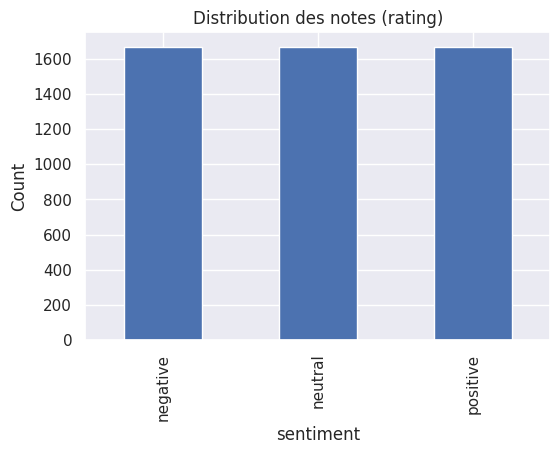

In [3]:
df["text_length"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

display(df[["text_length","word_count"]].describe(include="all"))

plt.figure(figsize=(6,4))
df["sentiment"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution des notes (rating)")
plt.xlabel("sentiment")
plt.ylabel("Count")
plt.show()

In [4]:
# Stopwords FR + EN (NLTK)
nltk.download('stopwords')
stop_fr = set(stopwords.words("french"))
stop_en = set(stopwords.words("english"))
stop_all = stop_fr | stop_en
stop_all

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ai',
 'aie',
 'aient',
 'aies',
 'ain',
 'ait',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'au',
 'aura',
 'aurai',
 'auraient',
 'aurais',
 'aurait',
 'auras',
 'aurez',
 'auriez',
 'aurions',
 'aurons',
 'auront',
 'aux',
 'avaient',
 'avais',
 'avait',
 'avec',
 'avez',
 'aviez',
 'avions',
 'avons',
 'ayant',
 'ayante',
 'ayantes',
 'ayants',
 'ayez',
 'ayons',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'c',
 'can',
 'ce',
 'ces',
 'couldn',
 "couldn't",
 'd',
 'dans',
 'de',
 'des',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'du',
 'during',
 'each',
 'elle',
 'en',
 'es',
 'est',
 'et',
 'eu',
 'eue',
 'eues',
 'eurent',
 'eus',
 'eusse',
 'eussent',
 'eusses',
 'eussiez',
 'eussions',
 'eut',
 'eux',
 'eûmes',
 'eût',
 'eûtes',
 'few',
 'for',
 'from',
 'furent',
 'furth

In [5]:
# On garde les négations (très utiles en sentiment)
NEGATIONS = {"ne", "pas", "jamais", "rien", "plus", "aucun", "sans", "not", "no", "never", "n't"}
stop_for_cloud_and_models = stop_all - NEGATIONS

In [6]:
# Nettoyage minimal : on garde ! ? (peuvent porter du sentiment)
PUNCT_TO_REMOVE = set(string.punctuation) - set(["!", "?"])

In [7]:
def basic_clean(text: str) -> str:
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)  # URLs
    text = re.sub(r"<.*?>", " ", text)            # HTML
    text = re.sub(r"\s+", " ", text).strip()     # espaces multiples
    return text
df["text_clean"] = df["text"].apply(basic_clean)

In [8]:
nltk.download('punkt')
nltk.download('punkt_tab')
def tokenize(text: str):
    return word_tokenize(text)
df["tokens"] = df["text_clean"].apply(tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [9]:
def normalize_tokens(tokens):
    out = []
    for t in tokens:
        t = t.lower()

        # retire ponctuation (sauf ! ?)
        if t in PUNCT_TO_REMOVE:
            continue

        # retire tokens trop courts (évite n, t, etc.)
        if len(t) <= 2 and t not in NEGATIONS:
            continue

        # retire stopwords (sauf négations)
        if t in stop_for_cloud_and_models:
            continue

        # conserve les tokens contenant au moins une lettre
        if not re.search(r"[a-zA-ZÀ-ÿ]", t):
            continue

        out.append(t)
    return out

df["tokens"] = df["tokens"].apply(normalize_tokens)

In [10]:
df[["text","text_clean","tokens"]].head()

,text,text_clean,tokens
0,"Franchement, Outstanding! Meilleur achat de l'...","Franchement, Outstanding! Meilleur achat de l'...","[franchement, outstanding, meilleur, achat, l'..."
1,"Warning: Horrible experience, vraiment pas sat...","Warning: Horrible experience, vraiment pas sat...","[warning, horrible, experience, vraiment, pas,..."
2,Hélas... Je regrette cet achat... Totally disa...,Hélas... Je regrette cet achat... Totally disa...,"[hélas, regrette, cet, achat, totally, disappo..."
3,Excellent rapport qualité-prix! Highly recomme...,Excellent rapport qualité-prix! Highly recomme...,"[excellent, rapport, qualité-prix, highly, rec..."
4,"Franchement, Super expérience, very satisfied ...","Franchement, Super expérience, very satisfied ...","[franchement, super, expérience, satisfied, or..."


In [11]:
all_words = [w for toks in df["tokens"] for w in toks]
freq = Counter(all_words)
print("Top 20 mots:", freq.most_common(20))

Top 20 mots: [('pas', 768), ("c'est", 736), ('vraiment', 683), ('service', 593), ('quality', 587), ('not', 531), ('bon', 469), ('disappointed', 462), ('très', 446), ('verra', 446), ('produit', 370), ('voilà', 355), ('correct', 349), ('ne', 348), ('experience', 333), ("'ll", 329), ('see', 329), ('well', 321), ('warning', 298), ('sérieusement', 292)]


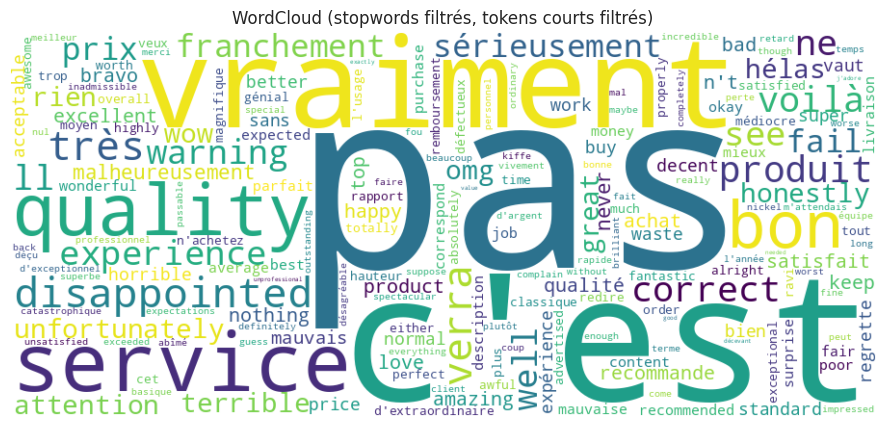

In [12]:
plt.figure(figsize=(12,5))
wc = WordCloud(width=900, height=400, background_color="white", collocations=False)
wc.generate(" ".join(all_words))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud (stopwords filtrés, tokens courts filtrés)")
plt.show()

In [13]:
try:
    nlp_en = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading en_core_web_sm model...")
    spacy.cli.download("en_core_web_sm")
    nlp_en = spacy.load("en_core_web_sm")

try:
    nlp_fr = spacy.load("fr_core_news_sm")
except OSError:
    print("Downloading fr_core_news_sm model...")
    spacy.cli.download("fr_core_news_sm")
    nlp_fr = spacy.load("fr_core_news_sm")

✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [14]:
def spacy_process(text):
    doc = nlp_fr(text)   # ou nlp_en
    lemmas = []
    pos_tags = []

    for tok in doc:
        if tok.is_space:
            continue
        lem = tok.lemma_.lower()
        if lem in stop_for_cloud_and_models and lem not in NEGATIONS:
            continue
        if len(lem) <= 2 and lem not in NEGATIONS:
            continue
        if lem in PUNCT_TO_REMOVE:
            continue
        if not re.search(r"[a-zA-ZÀ-ÿ]", lem):
            continue
        lemmas.append(lem)
        pos_tags.append(tok.pos_)

    return lemmas, pos_tags
tmp = []
for _, row in df.iterrows():
    lem, pos = spacy_process(row["text_clean"])
    tmp.append((lem, pos))

df["lemmas"] = [t[0] for t in tmp]
df["pos"] = [t[1] for t in tmp]

df.head()

,id,text,sentiment,text_length,word_count,text_clean,tokens,lemmas,pos
0,1,"Franchement, Outstanding! Meilleur achat de l'...",positive,57,8,"Franchement, Outstanding! Meilleur achat de l'...","[franchement, outstanding, meilleur, achat, l'...","[franchement, outstanding, meilleur, achat, an...","[ADV, PROPN, ADJ, NOUN, NOUN]"
1,2,"Warning: Horrible experience, vraiment pas sat...",negative,58,8,"Warning: Horrible experience, vraiment pas sat...","[warning, horrible, experience, vraiment, pas,...","[warning, horrible, experience, vraiment, pas,...","[PROPN, NOUN, VERB, ADV, ADV, ADJ]"
2,3,Hélas... Je regrette cet achat... Totally disa...,negative,69,10,Hélas... Je regrette cet achat... Totally disa...,"[hélas, regrette, cet, achat, totally, disappo...","[hélas, regretter, achat, totally, disappointe...","[INTJ, VERB, NOUN, PROPN, PROPN, VERB]"
3,4,Excellent rapport qualité-prix! Highly recomme...,positive,52,6,Excellent rapport qualité-prix! Highly recomme...,"[excellent, rapport, qualité-prix, highly, rec...","[excellent, rapport, qualité, prix, highly, re...","[ADJ, NOUN, PROPN, NOUN, NOUN, VERB]"
4,5,"Franchement, Super expérience, very satisfied ...",positive,69,10,"Franchement, Super expérience, very satisfied ...","[franchement, super, expérience, satisfied, or...","[franchement, super, expérience, satisfied, or...","[ADV, PROPN, NOUN, ADV, VERB]"


In [15]:
vader = SentimentIntensityAnalyzer()
df["vader_score"] = df["text_clean"].apply(lambda x: vader.polarity_scores(x)["compound"])

In [16]:
# Sauvegarde des labels d'origine (gold) avant de les écraser avec VADER
# Le dataset contient souvent une colonne 'sentiment' (ex: rating/label). On la conserve pour l'évaluation ML/DL.
if "sentiment_gold" not in df.columns:
    if "sentiment" in df.columns:
        df["sentiment_gold"] = df["sentiment"].copy()
    elif "rating" in df.columns:
        df["sentiment_gold"] = df["rating"].copy()
    elif "label" in df.columns:
        df["sentiment_gold"] = df["label"].copy()

print("Colonnes disponibles:", list(df.columns))
print("Aperçu sentiment_gold:", df["sentiment_gold"].head() if "sentiment_gold" in df.columns else "⚠️ sentiment_gold non créé (colonne label introuvable).")


Colonnes disponibles: ['id', 'text', 'sentiment', 'text_length', 'word_count', 'text_clean', 'tokens', 'lemmas', 'pos', 'vader_score', 'sentiment_gold']
Aperçu sentiment_gold: 0    positive
1    negative
2    negative
3    positive
4    positive
Name: sentiment_gold, dtype: object


In [17]:
def vader_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["vader_score"].apply(vader_label)

In [18]:
df[["text_clean", "vader_score", "sentiment"]].head()

,text_clean,vader_score,sentiment
0,"Franchement, Outstanding! Meilleur achat de l'...",0.6476,positive
1,"Warning: Horrible experience, vraiment pas sat...",-0.7096,negative
2,Hélas... Je regrette cet achat... Totally disa...,-0.4778,negative
3,Excellent rapport qualité-prix! Highly recomme...,0.7257,positive
4,"Franchement, Super expérience, very satisfied ...",0.7902,positive


In [19]:
# Mini lexique FR pédagogique (à étendre)
LEX_FR = {
    "excellent": 2.0, "super": 1.5, "génial": 1.8, "parfait": 1.8, "rapide": 1.0, "recommande": 1.2,
    "déçu": -1.5, "mauvais": -2.0, "mauvaise": -2.0, "nulle": -2.0, "nul": -2.0, "terrible": -2.0, "arnaque": -2.2,
    "correct": 0.2, "moyen": -0.2, "ok": 0.1
}
BOOSTERS_FR = {"très": 1.3, "vraiment": 1.3, "extrêmement": 1.6}

In [21]:
def lexicon_score_fr(tokens):
    score = 0.0
    i = 0
    while i < len(tokens):
        t = tokens[i]
        mult = 1.0
        if t in BOOSTERS_FR and i + 1 < len(tokens):
            mult = BOOSTERS_FR[t]
            i += 1
            t = tokens[i]
        s = LEX_FR.get(t, 0.0) * mult
        if i - 1 >= 0 and tokens[i - 1] in NEGATIONS:
            s = -s
        score += s
        i += 1
    score = max(-1.0, min(1.0, score / max(1, len(tokens))))
    return score

def sentiment_label_from_score(score, pos_th=0.05, neg_th=-0.05):
    if score >= pos_th:
        return "positive"
    if score <= neg_th:
        return "negative"
    return "neutral"

def compute_lexical_sentiment(row):
    text = row["text_clean"]
    tokens = row["tokens"]
    if row["lang"] == "en":
        comp = vader.polarity_scores(text)["compound"]
        return comp, sentiment_label_from_score(comp)
    else:
        comp = lexicon_score_fr(tokens)
        return comp, sentiment_label_from_score(comp)

# --- FIX START ---
# Ensure langdetect is available (user might need to run !pip install langdetect in a separate cell)
try:
    from langdetect import detect
    from langdetect.lang_detect_exception import LangDetectException
except ImportError:
    print("Warning: 'langdetect' library not found. Please install it using: !pip install langdetect")
    print("Defaulting to 'fr' for all texts. Lexical sentiment results might be inaccurate for English texts.")
    def detect(text):
        return "fr"
    LangDetectException = Exception # Mock exception if langdetect is not installed

def get_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return "fr" # Default to French if detection fails for a particular text

# Add 'lang' column to df if it doesn't exist
if 'lang' not in df.columns:
    df['lang'] = df['text_clean'].apply(get_language)
# --- FIX END ---

df[["lex_score","lex_pred"]] = df.apply(lambda r: pd.Series(compute_lexical_sentiment(r)), axis=1)
df[["lang","text","sentiment","lex_score","lex_pred"]]

Defaulting to 'fr' for all texts. Lexical sentiment results might be inaccurate for English texts.


,lang,text,sentiment,lex_score,lex_pred
0,fr,"Franchement, Outstanding! Meilleur achat de l'...",positive,0.0,neutral
1,fr,"Warning: Horrible experience, vraiment pas sat...",negative,0.0,neutral
2,fr,Hélas... Je regrette cet achat... Totally disa...,negative,0.0,neutral
3,fr,Excellent rapport qualité-prix! Highly recomme...,positive,0.4,positive
4,fr,"Franchement, Super expérience, very satisfied ...",positive,0.3,positive
...,...,...,...,...,...
4995,fr,"Voilà, Pas mal without being great 😶 3/5",negative,0.0,neutral
4996,fr,Wow! Je suis très content! Great value for mon...,positive,0.0,neutral
4997,fr,"Unfortunately, C'est inadmissible! Completely ...",negative,0.0,neutral
4998,fr,It's alright. Rien d'extraordinaire ⭐⭐⭐,positive,0.0,neutral


Accuracy (lexicon-based): 0.3416

Classification report:
              precision    recall  f1-score   support

    negative      0.834     0.315     0.457      1728
     neutral      0.127     0.762     0.218       576
    positive      0.816     0.269     0.405      2696

    accuracy                          0.342      5000
   macro avg      0.593     0.449     0.360      5000
weighted avg      0.743     0.342     0.401      5000



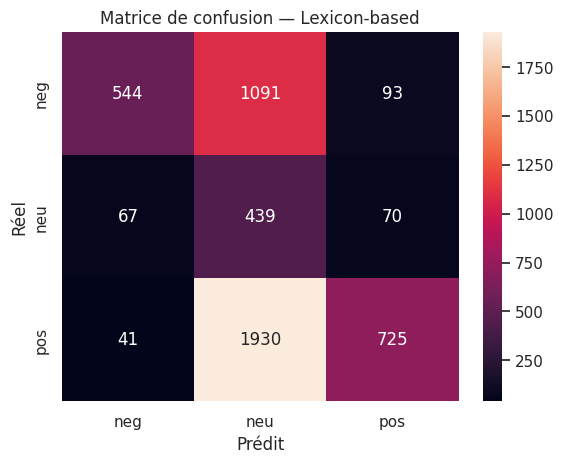

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy (lexicon-based):", accuracy_score(df["sentiment"], df["lex_pred"]))
print("\nClassification report:")
print(classification_report(df["sentiment"], df["lex_pred"], digits=3))

cm = confusion_matrix(df["sentiment"], df["lex_pred"], labels=["negative","neutral","positive"])
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["neg","neu","pos"], yticklabels=["neg","neu","pos"])
plt.title("Matrice de confusion — Lexicon-based")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


In [23]:
tests = [
    "I love this",
    "non, mais c'est beau",
    "This is not bad",
    "This is bad",
    "This is amazing!!!",
    "Yeah, great... 🙄"
]

for t in tests:
    print(t, vader.polarity_scores(t)["compound"])

I love this 0.6369
non, mais c'est beau 0.0
This is not bad 0.431
This is bad -0.5423
This is amazing!!! 0.6884
Yeah, great... 🙄 0.743


In [24]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder




In [25]:
TEXT_COL = "text_clean"      # utilise text_clean (string)
TARGET_COL = "sentiment"     # label (ex: negative/neutral/positive)

df_tmp = df[[TEXT_COL, TARGET_COL]].dropna().copy()
texts = df_tmp[TEXT_COL].astype(str).tolist()
y_raw = df_tmp[TARGET_COL].astype(str).tolist()

print(df_tmp.head())

                                          text_clean sentiment
0  Franchement, Outstanding! Meilleur achat de l'...  positive
1  Warning: Horrible experience, vraiment pas sat...  negative
2  Hélas... Je regrette cet achat... Totally disa...  negative
3  Excellent rapport qualité-prix! Highly recomme...  positive
4  Franchement, Super expérience, very satisfied ...  positive


In [26]:
# Encodage labels -> entiers
le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_
n_classes = len(class_names)

print("Classes:", list(class_names), "| n_classes =", n_classes)

Classes: [np.str_('negative'), np.str_('neutral'), np.str_('positive')] | n_classes = 3


In [27]:
# Split stratifié
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
from tensorflow.keras import layers, models
# ----------------------------- PREPROCESSING FOR EMBEDDING LAYER -----------------------------
# 1) Tokenization
MAX_WORDS = 10000 # Number of words to keep, based on word frequency
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<unk>")
tokenizer.fit_on_texts(X_train_text)

vocab_real = len(tokenizer.word_index) + 1 # +1 for padding index or OOV token
print(f"Taille du vocabulaire: {vocab_real}")

# 2) Convert text to sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_test_sequences = tokenizer.texts_to_sequences(X_test_text)

# 3) Padding sequences
MAX_LEN = max([len(x) for x in X_train_sequences]) # Max length of a sequence in training data
print(f"Longueur max des séquences: {MAX_LEN}")

X_train_pad = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding="post")
X_test_pad = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding="post")

# ----------------------------- MODEL DEFINITION -----------------------------
EMB_DIM = 64
EMB_DIM = 64
LSTM_UNITS = 64

model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),          # <- IMPORTANT
    layers.Embedding(input_dim=vocab_real, output_dim=EMB_DIM),
    layers.LSTM(LSTM_UNITS),
])

if n_classes == 2:
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
else:
    model.add(layers.Dense(n_classes, activation="softmax"))
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Taille du vocabulaire: 308
Longueur max des séquences: 13


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,931 (206.76 KB)

 Trainable params: 52,931 (206.76 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# -----------------------------
# 4) Entraînement rapide + évaluation
# -----------------------------
EPOCHS = 10
BATCH_SIZE = 32

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6629 - loss: 0.7285 - val_accuracy: 0.9750 - val_loss: 0.0861
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9843 - loss: 0.0448 - val_accuracy: 0.9862 - val_loss: 0.0413
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9897 - loss: 0.0388 - val_accuracy: 0.9937 - val_loss: 0.0312
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9892 - loss: 0.0394 - val_accuracy: 0.9925 - val_loss: 0.0272
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9931 - loss: 0.0277 - val_accuracy: 0.9950 - val_loss: 0.0226
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9956 - loss: 0.0189 - val_accuracy: 0.9925 - val_loss: 0.0226
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9947 - loss: 0.0206 - val_accuracy: 0.9962 - val_loss: 0.0154
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9958 - loss: 0.0137 - val_accuracy:

In [35]:
# Prédictions
if n_classes == 2:
    y_proba = model.predict(X_test_pad).ravel()
    y_pred = (y_proba >= 0.5).astype(int)
else:
    y_proba = model.predict(X_test_pad)
    y_pred = np.argmax(y_proba, axis=1)

print("\nAccuracy test:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=class_names))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Accuracy test: 0.992

Classification report:
               precision    recall  f1-score   support

    negative       0.99      0.99      0.99       346
     neutral       0.96      1.00      0.98       115
    positive       1.00      0.99      1.00       539

    accuracy                           0.99      1000
   macro avg       0.98      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

Confusion matrix:
 [[341   5   0]
 [  0 115   0]
 [  3   0 536]]


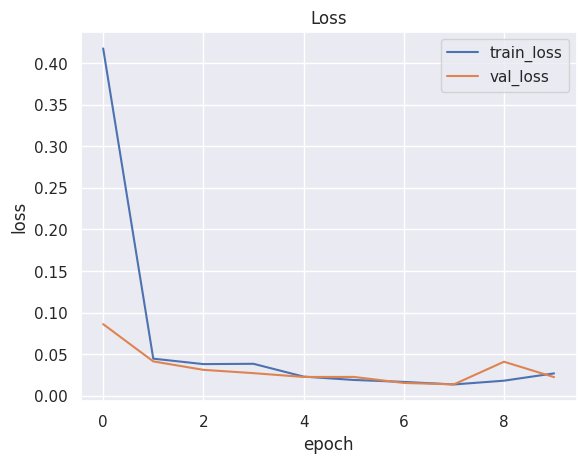

In [36]:
# -----------------------------
# 5) Courbes loss / accuracy
# -----------------------------
plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

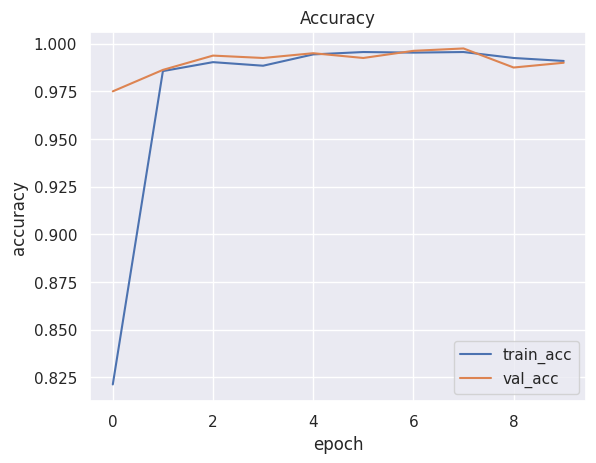

In [37]:
plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

## Modèles Machine Learning (TF‑IDF + Classifieurs)

Dans cette partie, on entraîne des modèles supervisés classiques sur des features **TF‑IDF** :
- Régression Logistique
- SVM linéaire
- Naive Bayes (Multinomial)

On évalue avec Accuracy, F1, matrice de confusion.


Taille dataset ML: (5000, 4)
Distribution des classes:


,count
y,
positive,1667
negative,1667
neutral,1666


TF-IDF shape: (4000, 969)

Modèle: LogisticRegression
Accuracy: 1.0
              precision    recall  f1-score   support

    negative      1.000     1.000     1.000       334
     neutral      1.000     1.000     1.000       333
    positive      1.000     1.000     1.000       333

    accuracy                          1.000      1000
   macro avg      1.000     1.000     1.000      1000
weighted avg      1.000     1.000     1.000      1000


Modèle: LinearSVC
Accuracy: 1.0
              precision    recall  f1-score   support

    negative      1.000     1.000     1.000       334
     neutral      1.000     1.000     1.000       333
    positive      1.000     1.000     1.000       333

    accuracy                          1.000      1000
   macro avg      1.000     1.000     1.000      1000
weighted avg      1.000     1.000     1.000      1000


Modèle: MultinomialNB
Accuracy: 1.0
              precision    recall  f1-score   support

    negative      1.000     1.000     1.000  

,Model,Accuracy
0,LogisticRegression,1.0
1,LinearSVC,1.0
2,MultinomialNB,1.0


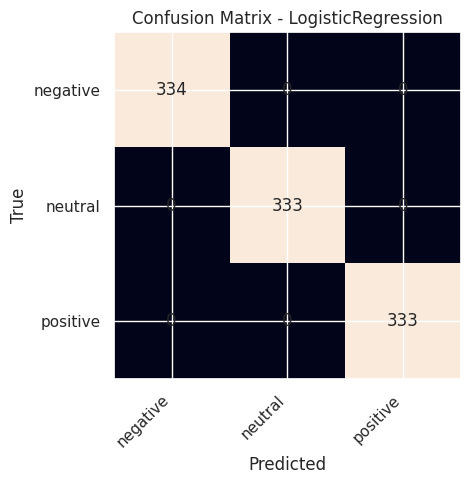


Classe: negative
  Mots/ngrams les + associés: ['disappointed' 'pas' 'warning' 'hélas' 'unfortunately' 'fail'
 'malheureusement' 'attention' 'terrible' 'vraiment pas' 'again' 'ne'
 'buy' 'poor' 'mauvaise' 'très mauvaise' 'horrible' 'never again' 'never'
 'vraiment']
  Mots/ngrams les - associés: ['bon' 'it' 'great' 'sérieusement' 'so' 'franchement' 'wow' 'omg' 'voilà'
 'honestly' 'correct' 'well' 'amazing' 'bravo' 'happy' 'top' 'on'
 'on verra' 'verra' 'rien']

Classe: neutral
  Mots/ngrams les + associés: ['correct' 'voilà' 'bon' 'well' 'rien' 'so' 'on' 'verra' 'on verra'
 'nothing' 'the' 'decent' 'sans' 'acceptable' 'mieux' 'average' 'job' 'ni'
 'standard' 'okay']
  Mots/ngrams les - associés: ['vraiment' 'très' 'disappointed' 'je' 'sérieusement' 'pas' 'ne' 'wow'
 'franchement' 'warning' 'honestly' 'omg' 'hélas' 'unfortunately' 'love'
 'attention' 'fail' 'malheureusement' 'bravo' 'this']

Classe: positive
  Mots/ngrams les + associés: ['sérieusement' 'franchement' 'wow' 'omg' 'hones

In [38]:
# -----------------------------
# 1) Choix de la cible (labels)
# -----------------------------
TEXT_COL = "text_clean"  # texte nettoyé
# on préfère les labels du dataset (gold) si disponibles, sinon ceux calculés par VADER
if "sentiment_gold" in df.columns:
    TARGET_COL = "sentiment_gold"
else:
    TARGET_COL = "sentiment"

df_ml = df[[TEXT_COL, TARGET_COL]].dropna().copy()

# Harmonisation: si la cible est numérique (ex: rating 1..5), on la convertit en 3 classes
import numpy as np
import pandas as pd

y_raw = df_ml[TARGET_COL]

if np.issubdtype(y_raw.dtype, np.number):
    # Heuristique standard: 1-2 négatif, 3 neutre, 4-5 positif
    def rating_to_sentiment(r):
        if r <= 2:
            return "negative"
        elif r == 3:
            return "neutral"
        else:
            return "positive"
    df_ml["y"] = y_raw.astype(int).apply(rating_to_sentiment)
else:
    df_ml["y"] = y_raw.astype(str)

df_ml["x"] = df_ml[TEXT_COL].astype(str)

print("Taille dataset ML:", df_ml.shape)
print("Distribution des classes:")
display(df_ml["y"].value_counts())

# -----------------------------
# 2) Split + TF-IDF
# -----------------------------
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_ml["x"],
    df_ml["y"],
    test_size=0.2,
    random_state=42,
    stratify=df_ml["y"]
)

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=2
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("TF-IDF shape:", X_train.shape)

# -----------------------------
# 3) Entraîner plusieurs modèles
# -----------------------------
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "LinearSVC": LinearSVC(class_weight="balanced"),
    "MultinomialNB": MultinomialNB()
}

results = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))
    print("\n" + "="*60)
    print("Modèle:", name)
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred, digits=3))

# -----------------------------
# 4) Comparaison simple
# -----------------------------
res_df = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
display(res_df)

# -----------------------------
# 5) Matrice de confusion pour le meilleur modèle
# -----------------------------
best_name = res_df.iloc[0]["Model"]
best_clf = models[best_name]
y_pred_best = best_clf.predict(X_test)

labels = sorted(df_ml["y"].unique())
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix - {best_name}")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

# -----------------------------
# 6) (Optionnel) Features les plus influentes (LogReg)
# -----------------------------
if best_name == "LogisticRegression":
    # One-vs-rest: coef_ shape = (n_classes, n_features)
    feature_names = np.array(tfidf.get_feature_names_out())
    coefs = best_clf.coef_
    classes = best_clf.classes_

    top_n = 20
    for idx, cls in enumerate(classes):
        top_pos = np.argsort(coefs[idx])[-top_n:][::-1]
        top_neg = np.argsort(coefs[idx])[:top_n]
        print("\nClasse:", cls)
        print("  Mots/ngrams les + associés:", feature_names[top_pos])
        print("  Mots/ngrams les - associés:", feature_names[top_neg])
